# **Dataset Generation for IROS Diffusion**

In [1]:
from typing import Callable

import numpy as np
from numpy.random import Generator
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from bloodmoon.coords import angle2shift, shift2pos
from bloodmoon.images import argmax
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import decode, variance, snratio
from bloodmoon.optim import model_shadowgram
import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if dataset == 'reconstructed' else False)
    return flag


BASE_PATH: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
MASK_PATH: str = f"{BASE_PATH}/mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1
DATASET: str = 'detected'

VIGNETTING: bool | Callable = False
PSFY: bool | Callable = config_psfy_flag(DATASET)

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

rnd_gen: Generator = np.random.default_rng()

In [3]:
def show_mat(m: NDArray, title: str = None, **kwargs) -> None:
    mat = plt.matshow(m, origin='lower', **kwargs)
    if title is not None: plt.title(title)
    plt.colorbar(mat, location='right', shrink=0.8, pad=0.05)
    plt.show()
    return

# def get_px_rate(camera: CodedMaskCamera, flx: NDArray) -> NDArray:
#     """Computes the counts rate from given `flx` [ph / s / cm2] on detector pixels."""
#     # pixel area in [cm^2]
#     px_area: float = (
#         1e-2 * camera.specs.mask_deltax * camera.specs.mask_deltay / np.prod(camera.upscale_f)
#     )
#     return flx * px_area
#
# def gen_poisson_noise(
#     camera: CodedMaskCamera,
#     n: int,
#     rmin: float = 0.2,
#     rmax: float = 10,
#     rng: Optional[Generator] = None,
# ) -> NDArray:
#     """
#     Generates array of shape `[n, d_h, d_w]` with `n` Poisson noise arrays
#     whose mean rate is defined by uniform distr between `rmin` and `rmax`.
#     """
#     if rng is None: rng = np.random.default_rng()
#     rates = rng.uniform(rmin, rmax, n)
#     p = [rng.poisson(lam=r, size=(1, *camera.shape_detector)) for r in rates]
#     return np.concat(p, axis=0)

In [4]:
rmin, rmax, n = 3, 10, 1

# flx = rnd_gen.uniform(fmin, fmax, n)
# px_rates = get_px_rate(wfm, flx)

px_rates = rnd_gen.uniform(rmin, rmax, n)

p = rnd_gen.poisson(lam=1, size=wfm.shape_detector)
# p = p / p.sum()

In [5]:
px_rates, p.sum(), p.mean(), p.std()

(array([4.26222376]),
 np.int64(388829),
 np.float64(0.9987593498273878),
 np.float64(1.000329245648087))

In [6]:
tx, ty = 10.3, 10.7   # [deg] (also analysing binning phase effect on sky image reconstruction)

sx, sy = map(lambda theta: angle2shift(wfm, theta), (tx, ty))
sg = model_shadowgram(wfm, sx, sy, VIGNETTING, PSFY, normalise=False)

In [7]:
detector = sg * p

detector.sum(), detector.mean(), detector.std()

(np.float64(124285.33403861131),
 np.float64(0.3192435220044882),
 np.float64(0.6906629218927052))

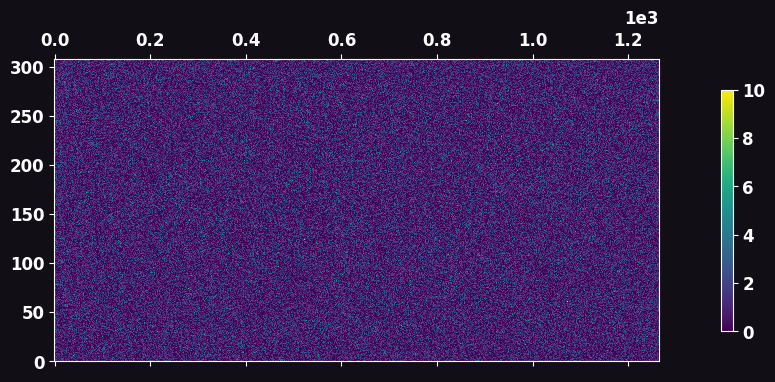

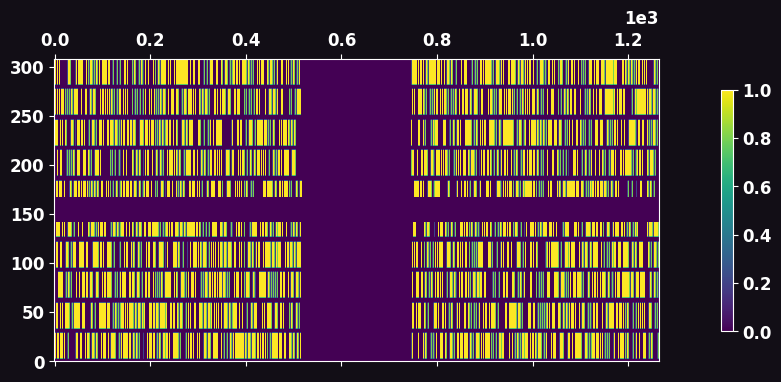

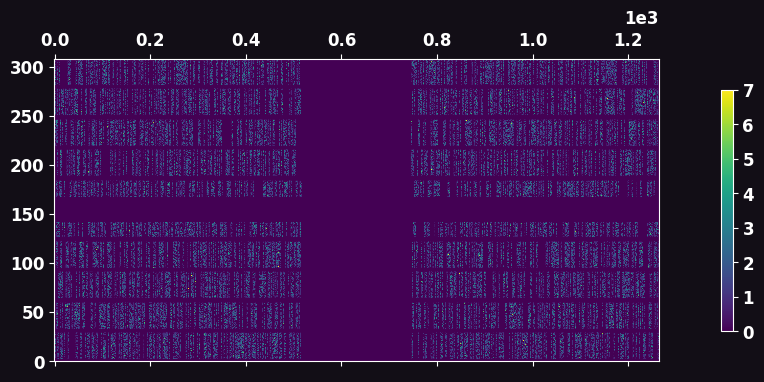

In [8]:
aspect = 0.5 * wfm.shape_detector[1] / wfm.shape_detector[0]

for arr in (p, sg, detector):
    show_mat(arr, aspect=aspect)

In [9]:
def find_boxmax(sky: NDArray, centre: tuple[int, int], boxsize: int = 5) -> tuple[int, int]:
    """Finds the argmax of given sky in a box centered around `pos`."""
    rcut, ccut = map(lambda idx: slice(idx - boxsize, idx + boxsize + 1), centre)
    p, q = centre
    n, m = argmax(sky[rcut, ccut])
    return p - boxsize + n, q - boxsize + m

def extract_spsf(
    camera: CodedMaskCamera,
    sky: NDArray,
    coords: tuple[float, float],
    crp: tuple[int, int] = (36, 4),
) -> NDArray:
    """
    Extracts source PSF from sky, centered around peak position.
    NOTE: peak position may not be the same as input position.
    """
    idxs = shift2pos(camera, *coords)
    y, x = find_boxmax(sky, idxs)
    crpy, crpx = crp
    rows, cols = slice(y - crpy, y + crpy + 1), slice(x - crpx, x + crpx + 1)
    return sky[rows, cols]

skymap = decode(wfm, detector)
varmap = variance(wfm, detector)
snrmap = snratio(skymap, varmap)

In [10]:
spsf = extract_spsf(wfm, skymap, coords=(sx, sy))
src_snr = extract_spsf(wfm, snrmap, coords=(sx, sy))

# for (arr, title) in ((detector, 'Shadowgram'), (spsf, 'Source PSF'), (src_snr, 'Source SNR')):
#     show_mat(arr, title=title)

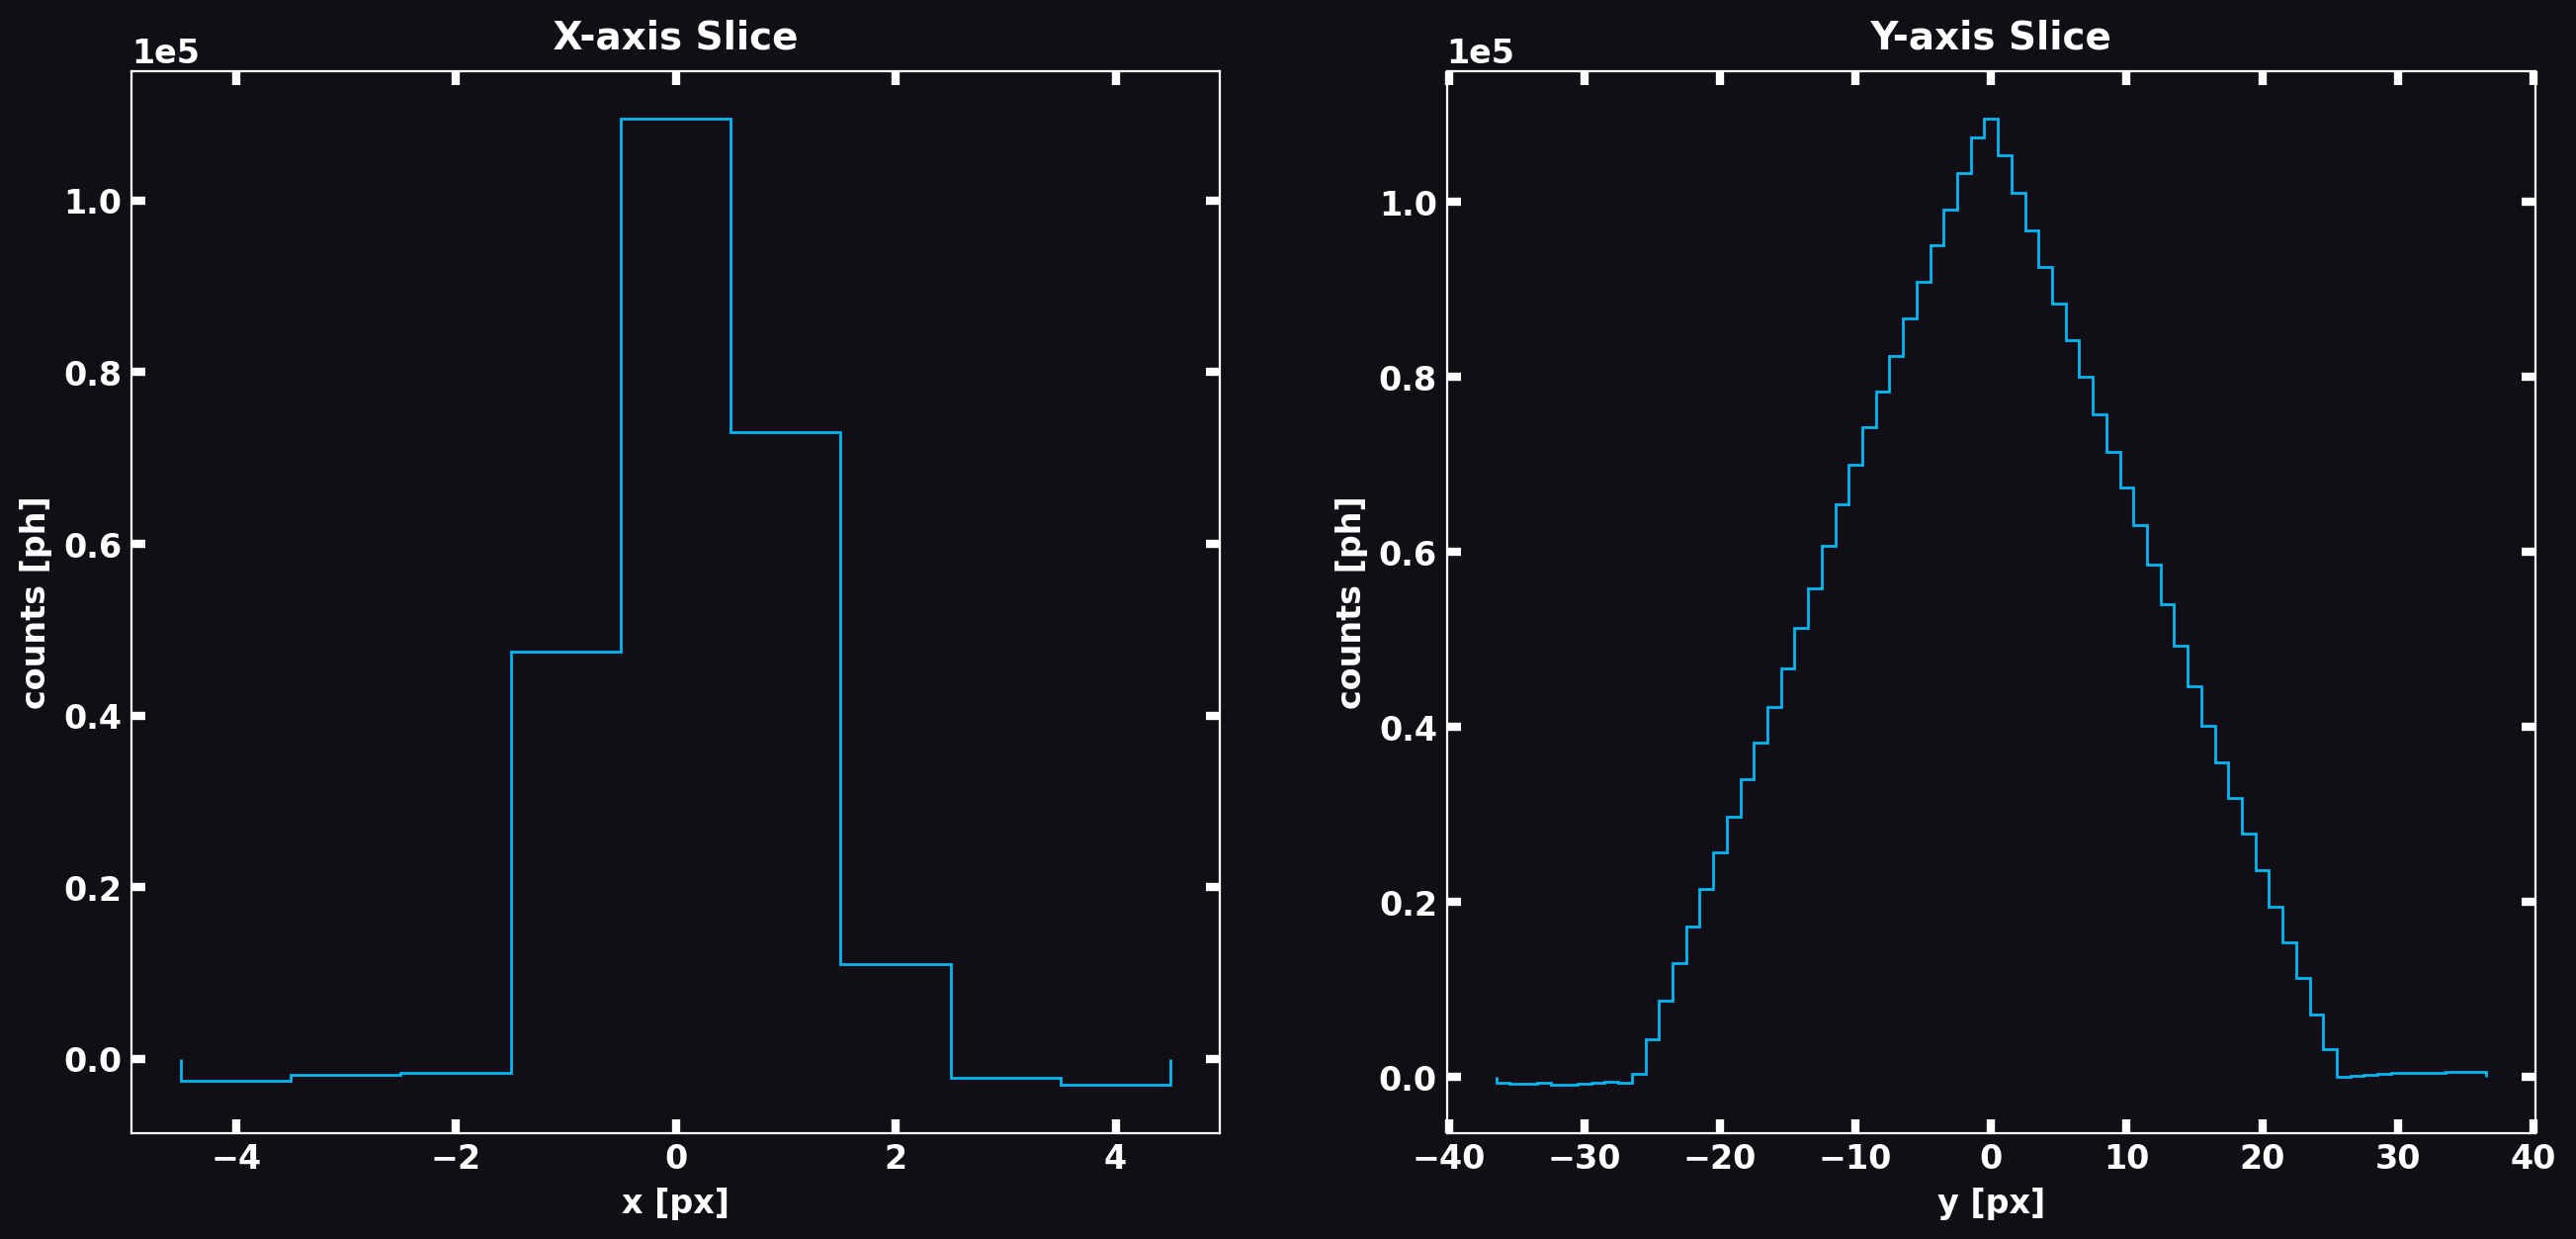

In [11]:
ds.slices_plot(skymap, find_boxmax(skymap, shift2pos(wfm, sx, sy)), crp=(36, 4), color='DeepSkyBlue')

In [12]:
def collapse_view(arr: NDArray) -> tuple[NDArray, NDArray]:
    """Collapses input 2D array by adding the elements along axes."""
    return np.sum(arr, axis=0), np.sum(arr, axis=1)

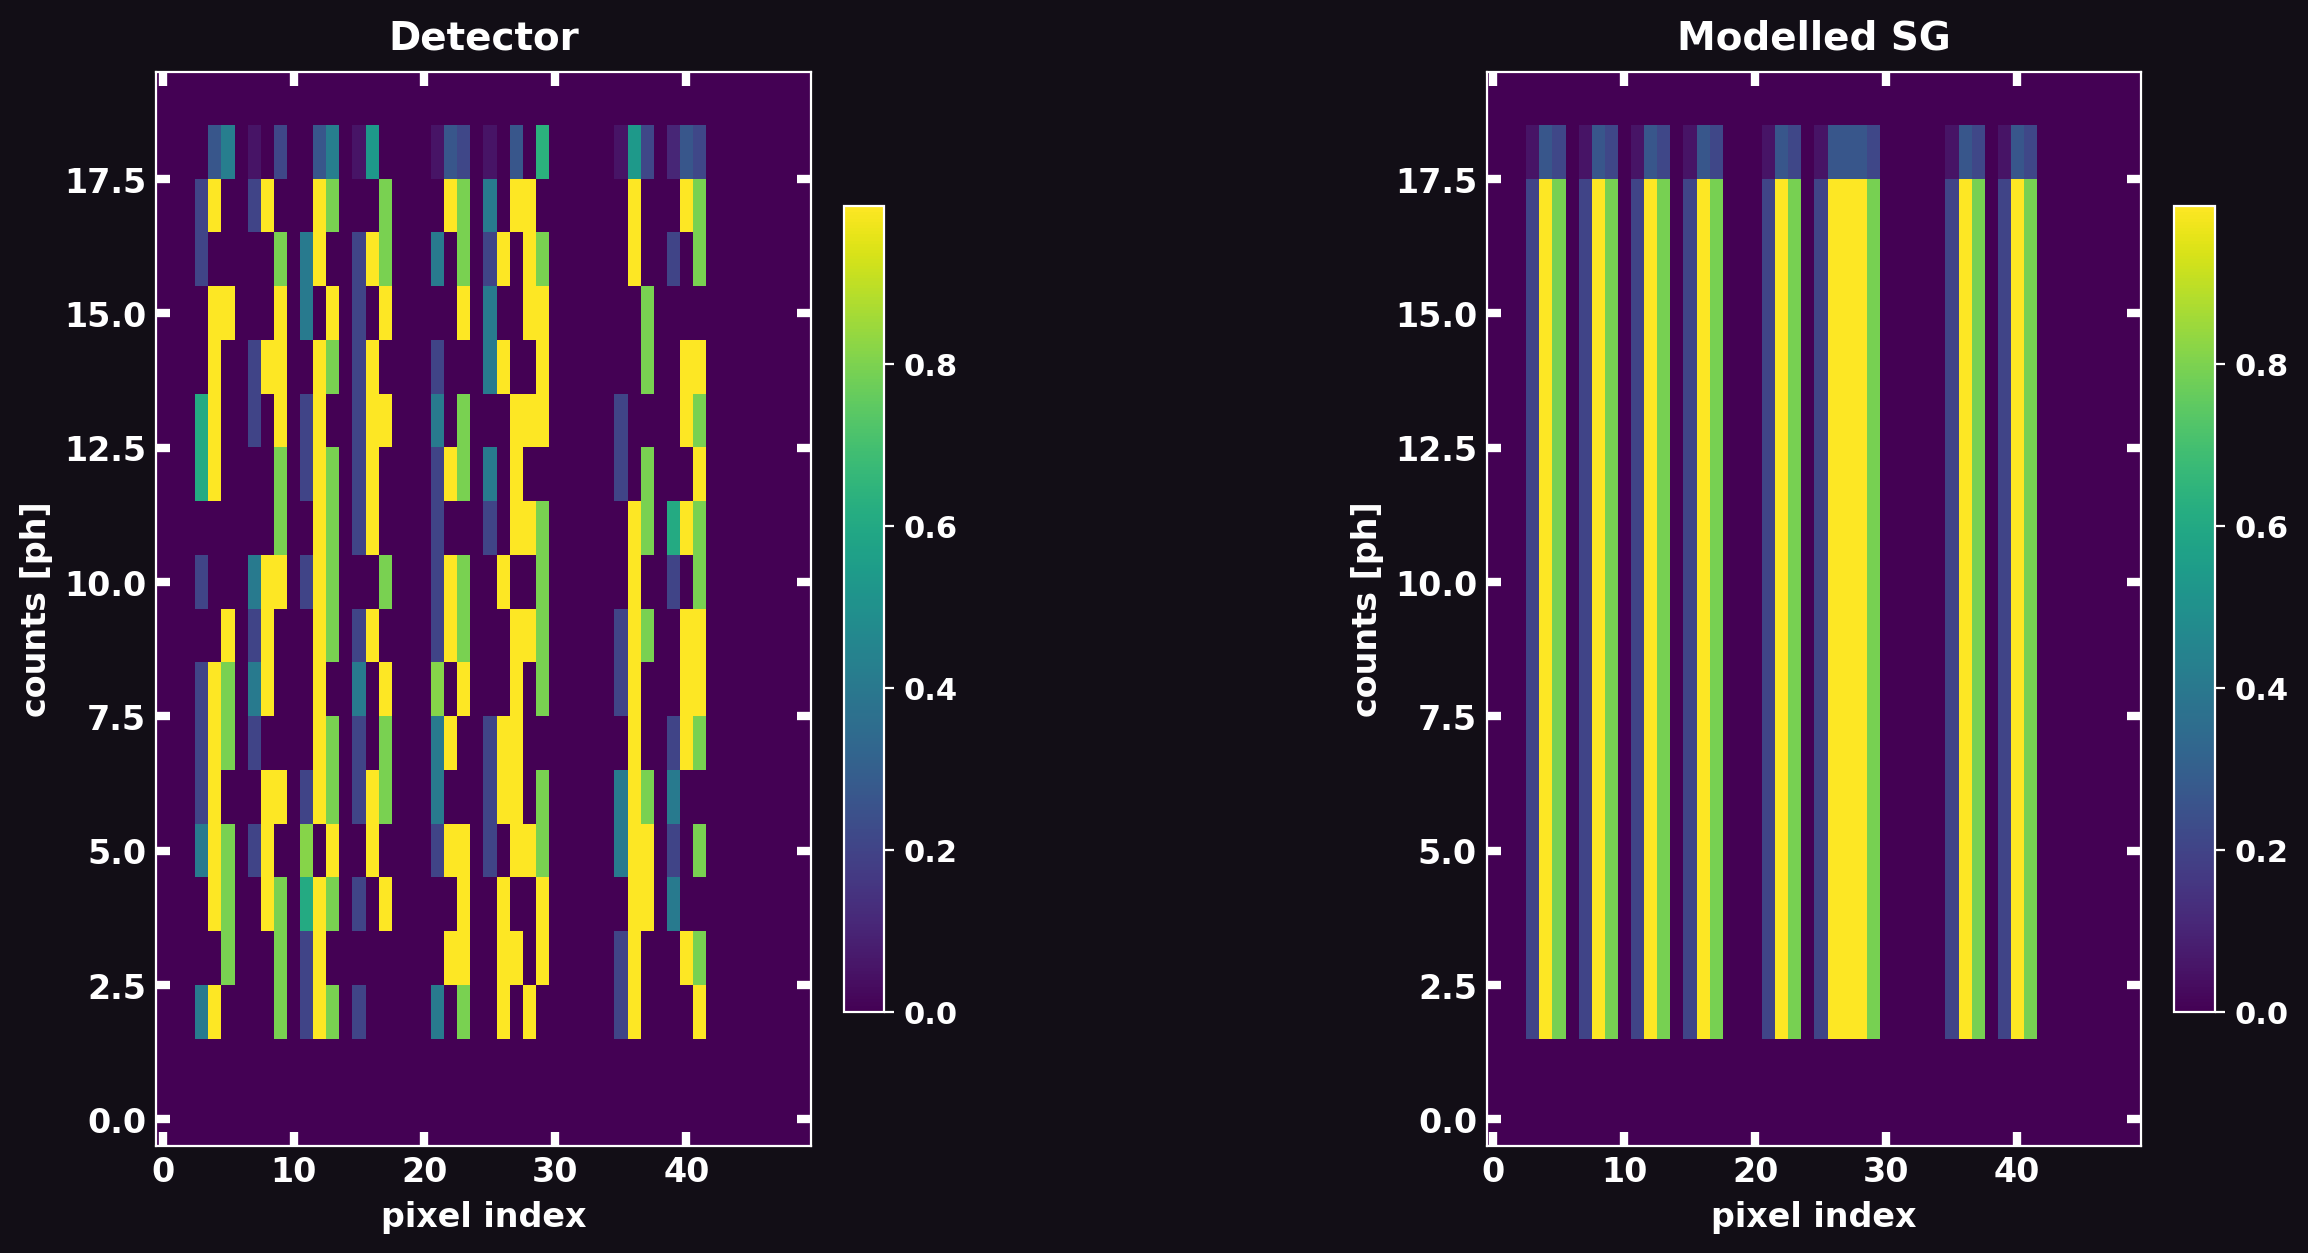

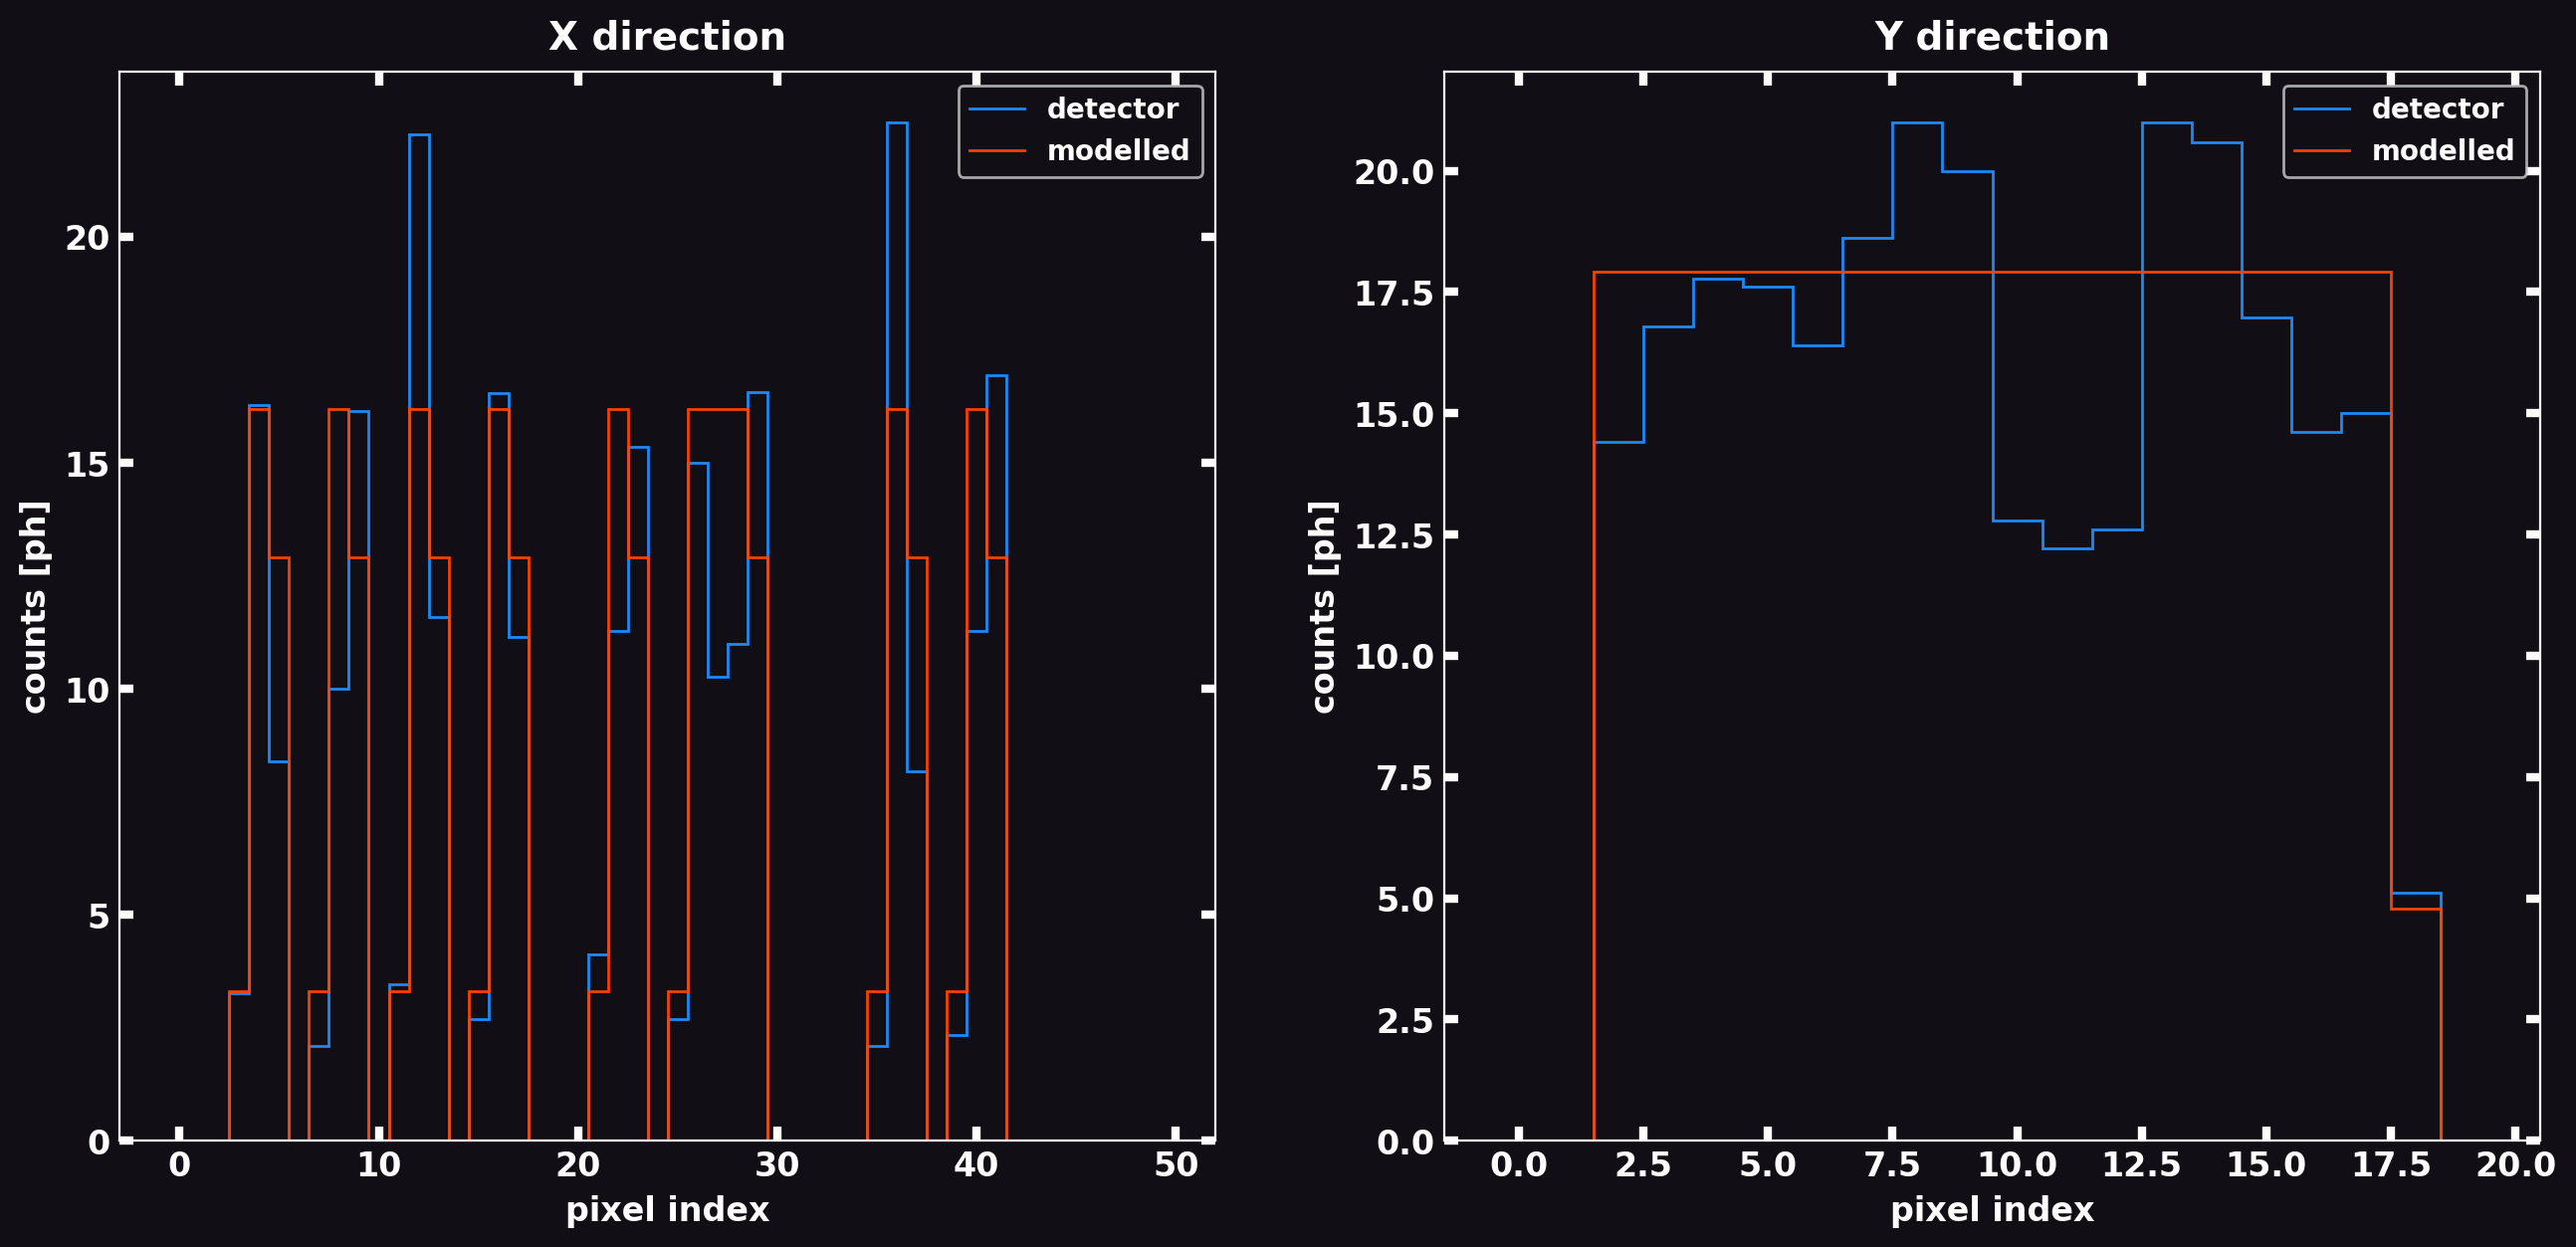

In [13]:
slicerows, slicecols = slice(165, 185), slice(375, 425)
ext_det, ext_sg = map(
    lambda x: x[slicerows, slicecols],
    (detector, sg * detector.sum() / sg.sum()),
)
det_x, det_y = collapse_view(ext_det)
sg_x, sg_y = collapse_view(ext_sg) 

aspect = wfm.shape_detector[1] / wfm.shape_detector[0]
dmap_img_det = ds.map4image(
    img=ext_det,
    title='Detector',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'vmax': ext_sg.max(),
        'aspect': aspect,
    }
)
dmap_img_sg = ds.map4image(
    img=ext_sg,
    title='Modelled SG',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'aspect': aspect,
    }
)
ds.image_plot((dmap_img_det, dmap_img_sg), ncols=2)

dmap_collapsed_x = ds.map4plot(
    arrs=(det_x, sg_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_x, sg_x)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(det_y, sg_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_y, sg_y)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
ds.plot((dmap_collapsed_x, dmap_collapsed_y), ncols=2)

In [ ]:
# NOTE: testing `decode()` vectorisation

from scipy.signal import fftconvolve

def vec_decode(camera: CodedMaskCamera, detector: NDArray) -> NDArray:
    """Vectorised balanced-sky decoding."""
    is_2d = detector.ndim == 2
    det = detector[None, ...] if is_2d else detector

    sum_bulk = camera.bulk.sum()
    sum_det = det.sum(axis=(-2, -1), keepdims=True)

    # using `fftconvolve` rather than `correlate`; FLIP detector to match correlation operation
    cc_bal = np.empty((det.shape[0], *camera.shape_sky), dtype=detector.dtype)
    cc_bal = fftconvolve(camera.decoder[None, ...], det[:, ::-1, ::-1], mode='full', axes=(-2, -1))
    cc_bal = cc_bal - camera.balancing[None, ...] * sum_det / sum_bulk

    return cc_bal[0] if is_2d else cc_bal

In [6]:
# NOTE: decoding through `decode` and `vec_decode` give same results, with abs diff < 1 (OK for sky arrays containing photon counts)

from tqdm import tqdm
from darksun.utils import benchmark_func

def gen_coords(camera: CodedMaskCamera, n: int, rng: Generator | None = None) -> NDArray:
    """Generates `n` random camera local-frame coords in `84° x 84°` FoV."""
    if rng is None: rng = np.random.default_rng()
    lim = angle2shift(camera, 42)
    return rng.uniform(-lim, lim, (n, 2))

def gen_shadowgrams(camera: CodedMaskCamera, coords: NDArray, rates: NDArray, rng: Generator | None = None) -> NDArray:
    """Generates batch of shadowgrams."""
    if rng is None:
        rng = np.random.default_rng()

    n = coords.shape[0]
    sgs = np.empty((n, *camera.shape_detector), dtype=np.float32)
    for idx, (r, crd) in tqdm(enumerate(zip(rates, coords)), total=n, desc='Generating shadowgrams'):
        sx, sy = crd
        sgs[idx] = rng.poisson(r, size=camera.shape_detector) * model_shadowgram(camera, sx, sy, False, False, normalise=False)
    return sgs

def decode_batch(camera: CodedMaskCamera, detector: NDArray) -> NDArray:
    """Balanced-sky decoding from detector batch."""
    n = detector.shape[0]
    sky = np.empty((n, *wfm.shape_sky), dtype=np.float32)
    for idx, sg in tqdm(enumerate(detector), total=n, desc='Decoding shadowgrams'):
        sky[idx] = decode(camera, sg)
    return sky

N: int = 100
n_iters: int = 3

# generate shadowgrams
coords = gen_coords(wfm, N, rnd_gen)
rates = rnd_gen.uniform(0.1, 10, N)
sgs = gen_shadowgrams(wfm, coords, rates, rnd_gen)

Generating shadowgrams: 100%|██████████| 100/100 [00:03<00:00, 26.35it/s]


In [ ]:
# benchmark decoding
print('Benchmarking...')
avg, std, skies = benchmark_func(decode_batch, wfm, sgs, iterations=n_iters)
vec_avg, vec_std, vec_skies = benchmark_func(vec_decode, wfm, sgs, iterations=n_iters)
same_res = np.allclose(skies, vec_skies, atol=1)

print(
    f'Std `decode_batch` took: {avg} +/- {std} s\n'
    f'Vectorised `vec_decode` took: {vec_avg} +/- {vec_std} s\n'
    f'Same results: {same_res}\n'
)
if not same_res:
    res = skies - vec_skies
    print(
        f'Max diff: {res.max()}, min diff: {res.min()}\n'
        f'Residuals mean: {res.mean()} +/- {res.std()}\n'
    )


# NOTE: vectorised version seems to be slower and more memory consuming!!!